# Evaluación Formativa 1 — Código del informe
## Dataset: *E-Commerce Shipping Data* (entregas atrasadas)

**MCDI501 - Estadística Computacional para la Toma de Decisiones**
Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello
Equipo: José Ignacio Rodríguez, Yerko Gallardo y Sebastián Rojas

Este cuaderno reproduce los resultados del informe y sigue su mismo orden:

0. Configuración y carga de datos
1. Estadística descriptiva (ID1.2): tipos de variables, medidas resumen, frecuencias, figuras y calidad de datos
2. Estimación puntual e intervalos de confianza (ID1.3)
3. Pruebas de hipótesis (ID1.4)
4. Síntesis

## 0. Configuración y carga de datos

El archivo original `data/raw/ecommerce_shipping.csv` no se modifica. La base de trabajo `df` solo cambia
los nombres de las columnas y agrega `entrega_atrasada` (1 = atrasada, 0 = a tiempo). No se eliminan filas.

In [1]:
from pathlib import Path
import pandas as pd

# Raíz del proyecto: funciona al ejecutar desde la raíz o desde notebooks/
RAIZ = Path.cwd().resolve()
while not (RAIZ / 'pyproject.toml').exists():
    RAIZ = RAIZ.parent

raw = pd.read_csv(RAIZ / 'data/raw/ecommerce_shipping.csv', encoding='utf-8-sig')

NOMBRES = {
    'ID': 'id_envio', 'Warehouse_block': 'bloque_bodega', 'Mode_of_Shipment': 'modalidad_envio',
    'Customer_care_calls': 'llamadas_atencion', 'Customer_rating': 'calificacion_cliente',
    'Cost_of_the_Product': 'costo_producto', 'Prior_purchases': 'compras_previas',
    'Product_importance': 'importancia_producto', 'Gender': 'genero',
    'Discount_offered': 'descuento_ofrecido', 'Weight_in_gms': 'peso_gramos',
}
TARGET = 'entrega_atrasada'

df = raw.rename(columns=NOMBRES)
df[TARGET] = raw['Reached.on.Time_Y.N']
df['importancia_producto'] = pd.Categorical(df['importancia_producto'],
                                            categories=['low', 'medium', 'high'], ordered=True)

n = len(df)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (10999, 13)


,id_envio,bloque_bodega,modalidad_envio,llamadas_atencion,calificacion_cliente,costo_producto,compras_previas,importancia_producto,genero,descuento_ofrecido,peso_gramos,Reached.on.Time_Y.N,entrega_atrasada
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,1


## 1. Estadística descriptiva (ID1.2)

### 1.1 Tipos de variables y medidas resumen
Doce variables: un identificador, el resultado binario (`entrega_atrasada`), cinco cuantitativas (llamadas,
costo, compras previas, descuento y peso), tres nominales (bodega, modalidad y género) y dos ordinales
(calificación e importancia). La columna original del resultado (`Reached.on.Time_Y.N`) se conserva en `df`.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id_envio              10999 non-null  int64   
 1   bloque_bodega         10999 non-null  str     
 2   modalidad_envio       10999 non-null  str     
 3   llamadas_atencion     10999 non-null  int64   
 4   calificacion_cliente  10999 non-null  int64   
 5   costo_producto        10999 non-null  int64   
 6   compras_previas       10999 non-null  int64   
 7   importancia_producto  10999 non-null  category
 8   genero                10999 non-null  str     
 9   descuento_ofrecido    10999 non-null  int64   
 10  peso_gramos           10999 non-null  int64   
 11  Reached.on.Time_Y.N   10999 non-null  int64   
 12  entrega_atrasada      10999 non-null  int64   
dtypes: category(1), int64(9), str(3)
memory usage: 1.0 MB


In [2]:
tipos = pd.Series({
    'id_envio': 'Identificador (nominal)',
    'bloque_bodega': 'Cualitativa nominal',
    'modalidad_envio': 'Cualitativa nominal',
    'llamadas_atencion': 'Cuantitativa discreta (conteo)',
    'calificacion_cliente': 'Cualitativa ordinal (1 a 5)',
    'costo_producto': 'Cuantitativa de razón (USD)',
    'compras_previas': 'Cuantitativa discreta (conteo)',
    'importancia_producto': 'Cualitativa ordinal (low < medium < high)',
    'genero': 'Cualitativa nominal',
    'descuento_ofrecido': 'Cuantitativa (unidad no especificada)',
    'peso_gramos': 'Cuantitativa de razón (gramos)',
    'entrega_atrasada': 'Nominal binaria (resultado; 1 = atrasada)',
}, name='Tipo')
tipos.to_frame()

,Tipo
id_envio,Identificador (nominal)
bloque_bodega,Cualitativa nominal
modalidad_envio,Cualitativa nominal
llamadas_atencion,Cuantitativa discreta (conteo)
calificacion_cliente,Cualitativa ordinal (1 a 5)
costo_producto,Cuantitativa de razón (USD)
compras_previas,Cuantitativa discreta (conteo)
importancia_producto,Cualitativa ordinal (low < medium < high)
genero,Cualitativa nominal
descuento_ofrecido,Cuantitativa (unidad no especificada)


Medidas resumen de las variables cuantitativas (se excluyen el identificador, los códigos nominales y las
ordinales). Se agrega el rango intercuartílico (IQR) y la asimetría. Resultado exportado a
`outputs/tablas/descriptiva_cuantitativas.csv`.

In [4]:
cuantitativas = ['llamadas_atencion', 'costo_producto', 'compras_previas', 'descuento_ofrecido', 'peso_gramos']

desc = df[cuantitativas].describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc['asimetria'] = df[cuantitativas].skew()

(RAIZ / 'outputs/tablas').mkdir(parents=True, exist_ok=True)
desc.to_csv(RAIZ / 'outputs/tablas/descriptiva_cuantitativas.csv', encoding='utf-8')
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,asimetria
llamadas_atencion,10999.0,4.05,1.14,2.0,3.0,4.0,5.0,7.0,2.0,0.39
costo_producto,10999.0,210.20,48.06,96.0,169.0,214.0,251.0,310.0,82.0,-0.16
compras_previas,10999.0,3.57,1.52,2.0,3.0,3.0,4.0,10.0,1.0,1.68
descuento_ofrecido,10999.0,13.37,16.21,1.0,4.0,7.0,10.0,65.0,6.0,1.80
peso_gramos,10999.0,3634.02,1635.38,1001.0,1839.5,4149.0,5050.0,7846.0,3210.5,-0.25


### 1.2 Frecuencias de las variables cualitativas
Frecuencias absolutas y porcentajes, con las ordinales en su orden natural. Resultado exportado a
`outputs/tablas/frecuencias.csv`.

In [5]:
cualitativas = ['entrega_atrasada', 'modalidad_envio', 'bloque_bodega', 'genero',
                'importancia_producto', 'calificacion_cliente']

partes = []
for v in cualitativas:
    t = df[v].value_counts().sort_index().rename('n').to_frame()   # respeta el orden de las ordinales
    t['porcentaje'] = t['n'] / n * 100
    t.insert(0, 'categoria', t.index.astype(str))
    t.insert(0, 'variable', v)
    assert t['n'].sum() == n          # las frecuencias suman el total
    partes.append(t)

frecuencias = pd.concat(partes, ignore_index=True)
frecuencias.to_csv(RAIZ / 'outputs/tablas/frecuencias.csv', index=False, encoding='utf-8')

r = df['calificacion_cliente']
print(f"Calificación: mediana = {r.median():g}, Q1 = {r.quantile(0.25):g}, Q3 = {r.quantile(0.75):g}")
cod = int(df['importancia_producto'].cat.codes.median())
print(f"Importancia : mediana = {df['importancia_producto'].cat.categories[cod]}")
frecuencias.round(2)

Calificación: mediana = 3, Q1 = 2, Q3 = 4
Importancia : mediana = medium


,variable,categoria,n,porcentaje
0,entrega_atrasada,0,4436,40.33
1,entrega_atrasada,1,6563,59.67
2,modalidad_envio,Flight,1777,16.16
3,modalidad_envio,Road,1760,16.00
4,modalidad_envio,Ship,7462,67.84
5,bloque_bodega,A,1833,16.67
6,bloque_bodega,B,1833,16.67
7,bloque_bodega,C,1833,16.67
8,bloque_bodega,D,1834,16.67
9,bloque_bodega,F,3666,33.33


### Estilo de las figuras
Paleta común: fondo crema, verde azulado para la serie principal y terracota para las entregas atrasadas.

In [6]:
import matplotlib.pyplot as plt

TEAL  = '#2e6b75'   # serie principal
TERRA = '#a35140'   # entregas atrasadas
BG    = '#f6f1ea'   # fondo de los ejes
GRID  = '#ddd5c6'   # líneas de grilla

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200,
    'font.family': 'serif', 'font.size': 10,
    'axes.facecolor': BG, 'axes.edgecolor': '#8c8578',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titleweight': 'normal', 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
})
(RAIZ / 'outputs/figuras').mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


### Figura 1 - Resultado de la entrega, modalidad de envío y bodega

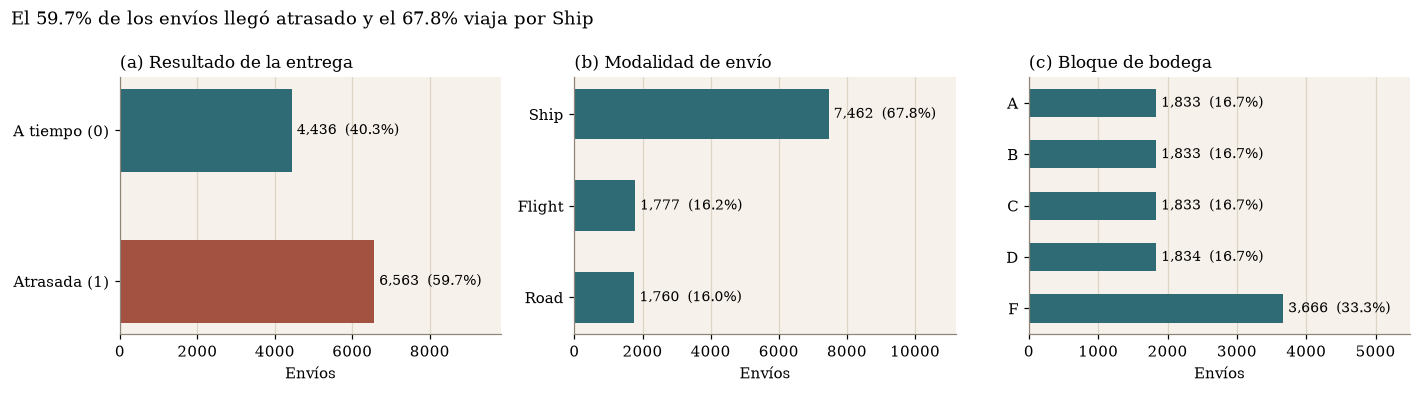

In [7]:
def barras(ax, serie, titulo, color=TEAL):
    ax.barh(serie.index.astype(str), serie.values, color=color, height=0.55)
    ax.invert_yaxis()
    for i, v in enumerate(serie.values):
        ax.text(v + serie.max() * 0.02, i, f'{v:,}  ({v/n*100:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(0, serie.max() * 1.5)
    ax.set_xlabel('Envíos')
    ax.set_title(titulo)
    ax.grid(axis='y', visible=False)

resultado = df[TARGET].value_counts().sort_index()
resultado.index = ['A tiempo (0)', 'Atrasada (1)']
modalidad = df['modalidad_envio'].value_counts()
bodega = df['bloque_bodega'].value_counts().sort_index()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
barras(ax[0], resultado, '(a) Resultado de la entrega', color=[TEAL, TERRA])
barras(ax[1], modalidad, '(b) Modalidad de envío')
barras(ax[2], bodega, '(c) Bloque de bodega')
fig.suptitle(f"El {resultado.iloc[1]/n*100:.1f}% de los envíos llegó atrasado y el {modalidad.iloc[0]/n*100:.1f}% viaja por {modalidad.index[0]}",
             x=0.01, ha='left', fontsize=12)

plt.tight_layout()
plt.savefig(RAIZ / 'outputs/figuras/fig_1_resultado_y_envio.png', bbox_inches='tight')
plt.show()

### Figura 3 - Calificación del cliente e importancia del producto
Ambas son ordinales: se conserva el orden de las categorías.

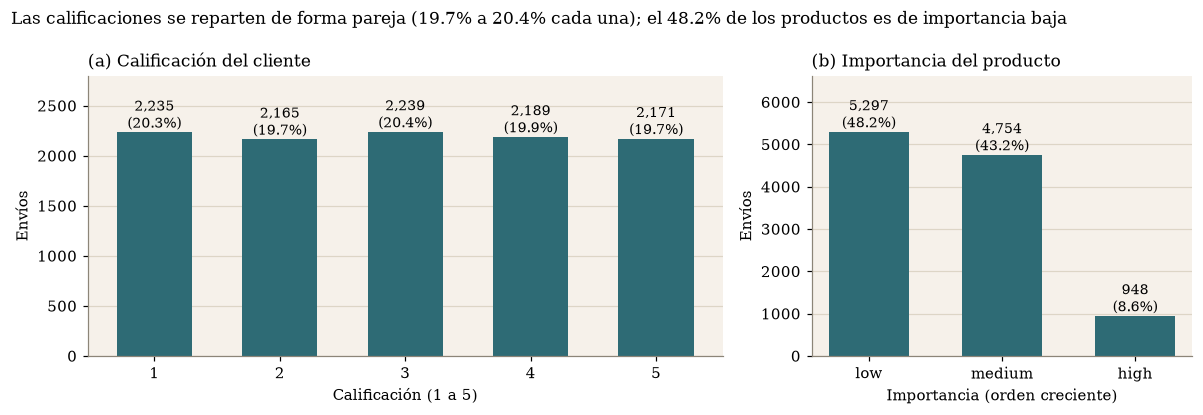

In [8]:
calif = df['calificacion_cliente'].value_counts().sort_index()
importancia = df['importancia_producto'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [5, 3]})
for a, serie, titulo, xlab in [(ax[0], calif, '(a) Calificación del cliente', 'Calificación (1 a 5)'),
                               (ax[1], importancia, '(b) Importancia del producto', 'Importancia (orden creciente)')]:
    a.bar(serie.index.astype(str), serie.values, color=TEAL, width=0.6)
    for i, v in enumerate(serie.values):
        a.text(i, v + serie.max() * 0.02, f'{v:,}\n({v/n*100:.1f}%)', ha='center', fontsize=9)
    a.set_ylim(0, serie.max() * 1.25)
    a.set_xlabel(xlab)
    a.set_ylabel('Envíos')
    a.set_title(titulo)
    a.grid(axis='x', visible=False)
fig.suptitle(f"Las calificaciones se reparten de forma pareja ({calif.min()/n*100:.1f}% a {calif.max()/n*100:.1f}% cada una); "
             f"el {importancia['low']/n*100:.1f}% de los productos es de importancia baja", x=0.01, ha='left', fontsize=11)

plt.tight_layout()
plt.savefig(RAIZ / 'outputs/figuras/fig_3_ordinales.png', bbox_inches='tight')
plt.show()

### 1.3 Calidad de datos
Nulos, duplicados, unicidad del identificador y tasa de atraso.

In [9]:
sin_id = [c for c in raw.columns if c != 'ID']

print(f"Registros                  : {n:,}")
print(f"Celdas vacías              : {raw.isna().sum().sum()}")
print(f"ID únicos                  : {df['id_envio'].nunique():,}")
print(f"Duplicados con ID          : {raw.duplicated().sum()}")
print(f"Duplicados sin ID          : {raw.duplicated(subset=sin_id).sum()}")
print(f"Entregas atrasadas         : {df[TARGET].sum():,} ({df[TARGET].mean()*100:.1f}%)")
print(f"Entregas a tiempo          : {(df[TARGET] == 0).sum():,} ({(1 - df[TARGET].mean())*100:.1f}%)")
print('Bodegas:', df['bloque_bodega'].value_counts().sort_index().to_dict())

Registros                  : 10,999
Celdas vacías              : 0
ID únicos                  : 10,999
Duplicados con ID          : 0
Duplicados sin ID          : 0
Entregas atrasadas         : 6,563 (59.7%)
Entregas a tiempo          : 4,436 (40.3%)
Bodegas: {'A': 1833, 'B': 1833, 'C': 1833, 'D': 1834, 'F': 3666}


### 1.4 Tabla de controles
Resumen de los controles, exportado a `outputs/tablas/calidad_datos.csv`. Estados: OK, ALERTA (revisar) e
INFO (extremos válidos, no es un error).

In [10]:
filas = []
def control(nombre, variable, esperado, observado, ok, detalle=''):
    filas.append((nombre, variable, esperado, observado, 'OK' if ok else 'ALERTA', detalle))

control('filas', 'todas', n, len(df), len(df) == n, 'Sin exclusiones de filas')
control('nulos_totales', 'todas', 0, int(raw.isna().sum().sum()), raw.isna().sum().sum() == 0, 'Sin imputación ni faltantes artificiales')
control('id_unico', 'id_envio', n, int(df['id_envio'].nunique()), df['id_envio'].is_unique, 'No prueba independencia ni un registro por cliente')

dominios = {'bloque_bodega': ['A', 'B', 'C', 'D', 'F'], 'modalidad_envio': ['Flight', 'Road', 'Ship'], 'genero': ['F', 'M']}
for v, esperado in dominios.items():
    obs = sorted(df[v].unique())
    control('dominio_categorico', v, esperado, obs, obs == esperado, 'F no se recodifica a E' if v == 'bloque_bodega' else '')
    control('suma_frecuencias', v, n, int(df[v].value_counts().sum()), df[v].value_counts().sum() == n)

obs = sorted(df['importancia_producto'].dropna().astype(str).unique())
control('dominio_ordinal', 'importancia_producto', 'low<medium<high', obs, obs == ['high', 'low', 'medium'])
control('dominio_ordinal', 'calificacion_cliente', '1..5', f"{df['calificacion_cliente'].min()}..{df['calificacion_cliente'].max()}", df['calificacion_cliente'].between(1, 5).all())
control('resultado_binario', TARGET, '{0,1}', sorted(df[TARGET].unique().tolist()), set(df[TARGET]) <= {0, 1},
        f"1 (atrasada)={df[TARGET].sum()}; 0 (a tiempo)={(df[TARGET] == 0).sum()}")
control('alias_igual_original', TARGET, 0, int((df[TARGET] != raw['Reached.on.Time_Y.N']).sum()), (df[TARGET] == raw['Reached.on.Time_Y.N']).all())

numericas = ['llamadas_atencion', 'costo_producto', 'compras_previas', 'descuento_ofrecido', 'peso_gramos']
for v in numericas:
    s = df[v]
    q1, q3 = s.quantile([0.25, 0.75])
    bajo, alto = int((s < q1 - 1.5 * (q3 - q1)).sum()), int((s > q3 + 1.5 * (q3 - q1)).sum())
    control('rango_valido', v, '>0', f'{s.min()}..{s.max()}', (s > 0).all())
    filas.append(('extremos_regla_IQR', v, 'conservar', f'bajo={bajo}; alto={alto}', 'INFO' if bajo + alto else 'OK',
                  'Valores válidos; no se eliminan' if bajo + alto else ''))

control('duplicados_con_ID', 'todas', 0, int(raw.duplicated().sum()), not raw.duplicated().any())
control('duplicados_sin_ID', 'todas menos ID', 0, int(raw.duplicated(subset=sin_id).sum()), not raw.duplicated(subset=sin_id).any(),
        'Perfiles idénticos no se eliminan automáticamente')

calidad = pd.DataFrame(filas, columns=['control', 'variable', 'esperado', 'observado', 'estado', 'detalle'])
(RAIZ / 'outputs/tablas').mkdir(parents=True, exist_ok=True)
calidad.to_csv(RAIZ / 'outputs/tablas/calidad_datos.csv', index=False, encoding='utf-8')

print(calidad['estado'].value_counts().to_dict())
calidad[['control', 'variable', 'observado', 'estado']]

{'OK': 23, 'INFO': 2}


,control,variable,observado,estado
0,filas,todas,10999,OK
1,nulos_totales,todas,0,OK
2,id_unico,id_envio,10999,OK
3,dominio_categorico,bloque_bodega,"[A, B, C, D, F]",OK
4,suma_frecuencias,bloque_bodega,10999,OK
5,dominio_categorico,modalidad_envio,"[Flight, Road, Ship]",OK
6,suma_frecuencias,modalidad_envio,10999,OK
7,dominio_categorico,genero,"[F, M]",OK
8,suma_frecuencias,genero,10999,OK
9,dominio_ordinal,importancia_producto,"[high, low, medium]",OK
